In [6]:
# STEP 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [7]:
# STEP 2: Load Iris and Breast Cancer datasets

# Iris Dataset
iris = datasets.load_iris(as_frame=True)

X_iris = iris.data
y_iris = iris.target

# Breast Cancer Dataset
cancer = datasets.load_breast_cancer(as_frame=True)

X_cancer = cancer.data
y_cancer = cancer.target

print("Iris Dataset Shape:", X_iris.shape)
print("Breast Cancer Dataset Shape:", X_cancer.shape)

print("\nIris Classes:", iris.target_names)
print("Breast Cancer Classes:", cancer.target_names)

Iris Dataset Shape: (150, 4)
Breast Cancer Dataset Shape: (569, 30)

Iris Classes: ['setosa' 'versicolor' 'virginica']
Breast Cancer Classes: ['malignant' 'benign']


In [8]:
# STEP 3: Explore Datasets

print("========== IRIS DATASET ==========")
print("\nFirst 5 Rows:")
print(X_iris.head())

print("\nColumn Names:")
print(X_iris.columns.tolist())

print("\nData Types:")
print(X_iris.dtypes)

print("\nShape:")
print(X_iris.shape)


print("\n\n========== BREAST CANCER DATASET ==========")
print("\nFirst 5 Rows:")
print(X_cancer.head())

print("\nColumn Names:")
print(X_cancer.columns.tolist())

print("\nData Types:")
print(X_cancer.dtypes)

print("\nShape:")
print(X_cancer.shape)

========== IRIS DATASET ==========

First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

Shape:
(150, 4)


========== BREAST CANCER DATASET ==========

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         

In [9]:
# STEP 4: Basic Statistics

print("========== IRIS DATASET STATISTICS ==========")
print(X_iris.describe())

print("\n\n========== BREAST CANCER DATASET STATISTICS ==========")
print(X_cancer.describe())

========== IRIS DATASET STATISTICS ==========
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


========== BREAST CANCER DATASET STATISTICS ==========
       mean radius  mean texture  mean perimeter    mean area  \
count   569.

In [10]:
# STEP 5: Check Missing Values

print("========== IRIS DATASET ==========")
print(X_iris.isnull().sum())

print("\nTotal Missing Values:", X_iris.isnull().sum().sum())

print("\n\n========== BREAST CANCER DATASET ==========")
print(X_cancer.isnull().sum())

print("\nTotal Missing Values:", X_cancer.isnull().sum().sum())

========== IRIS DATASET ==========
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Total Missing Values: 0


========== BREAST CANCER DATASET ==========
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst 

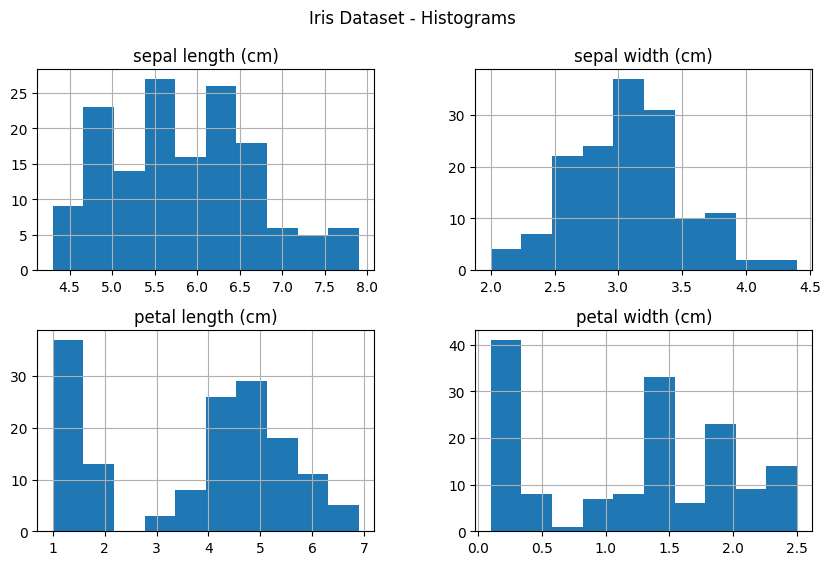

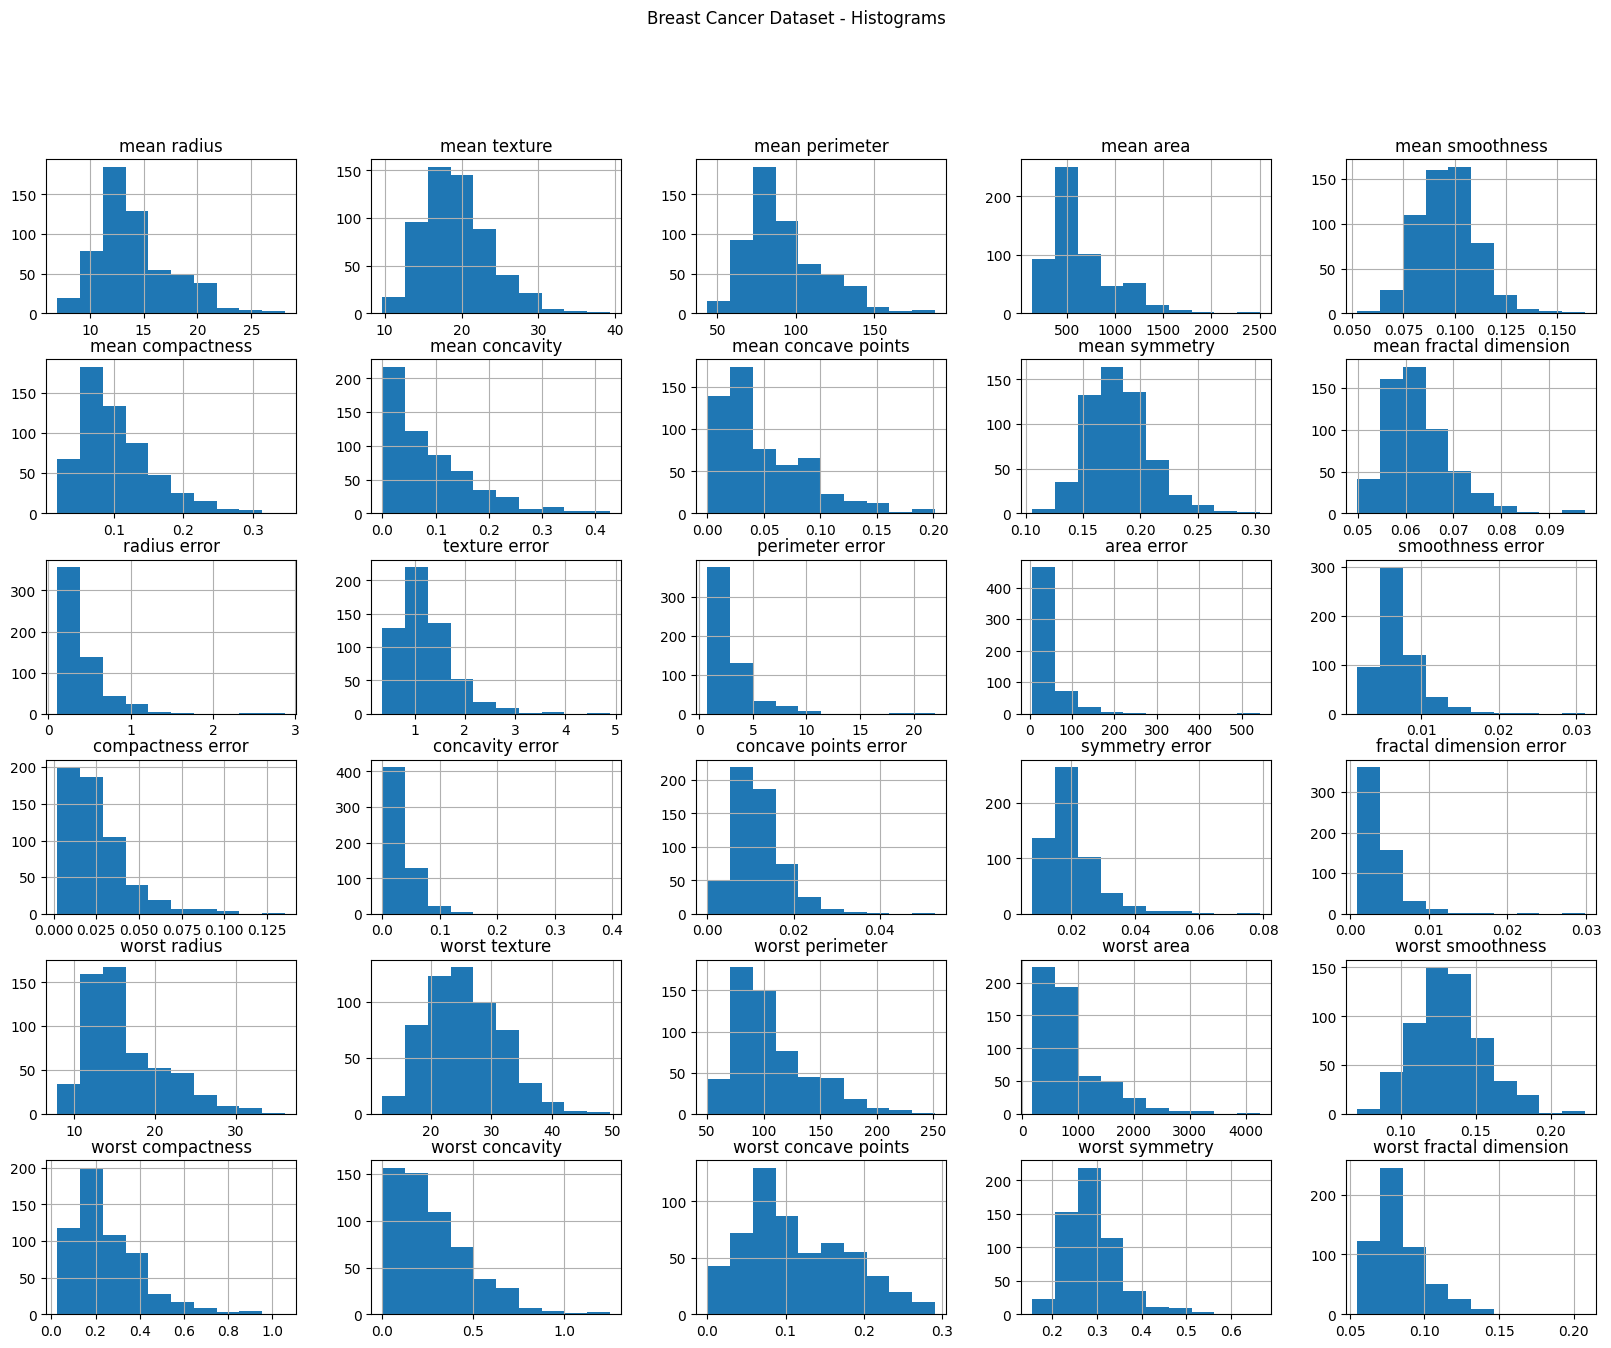

In [11]:
# STEP 6: Histograms

# Iris Dataset
X_iris.hist(figsize=(10,6))
plt.suptitle("Iris Dataset - Histograms")
plt.show()

# Breast Cancer Dataset
X_cancer.hist(figsize=(20,15))
plt.suptitle("Breast Cancer Dataset - Histograms")
plt.show()

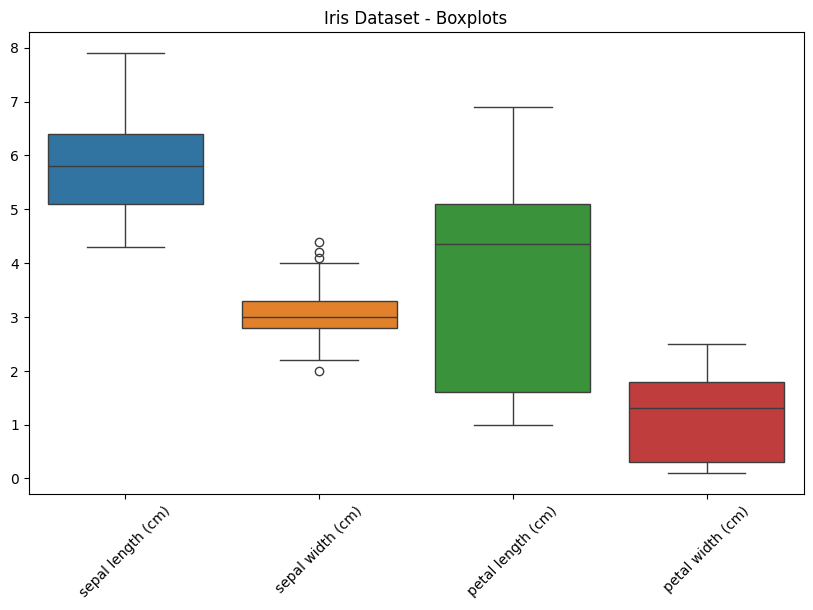

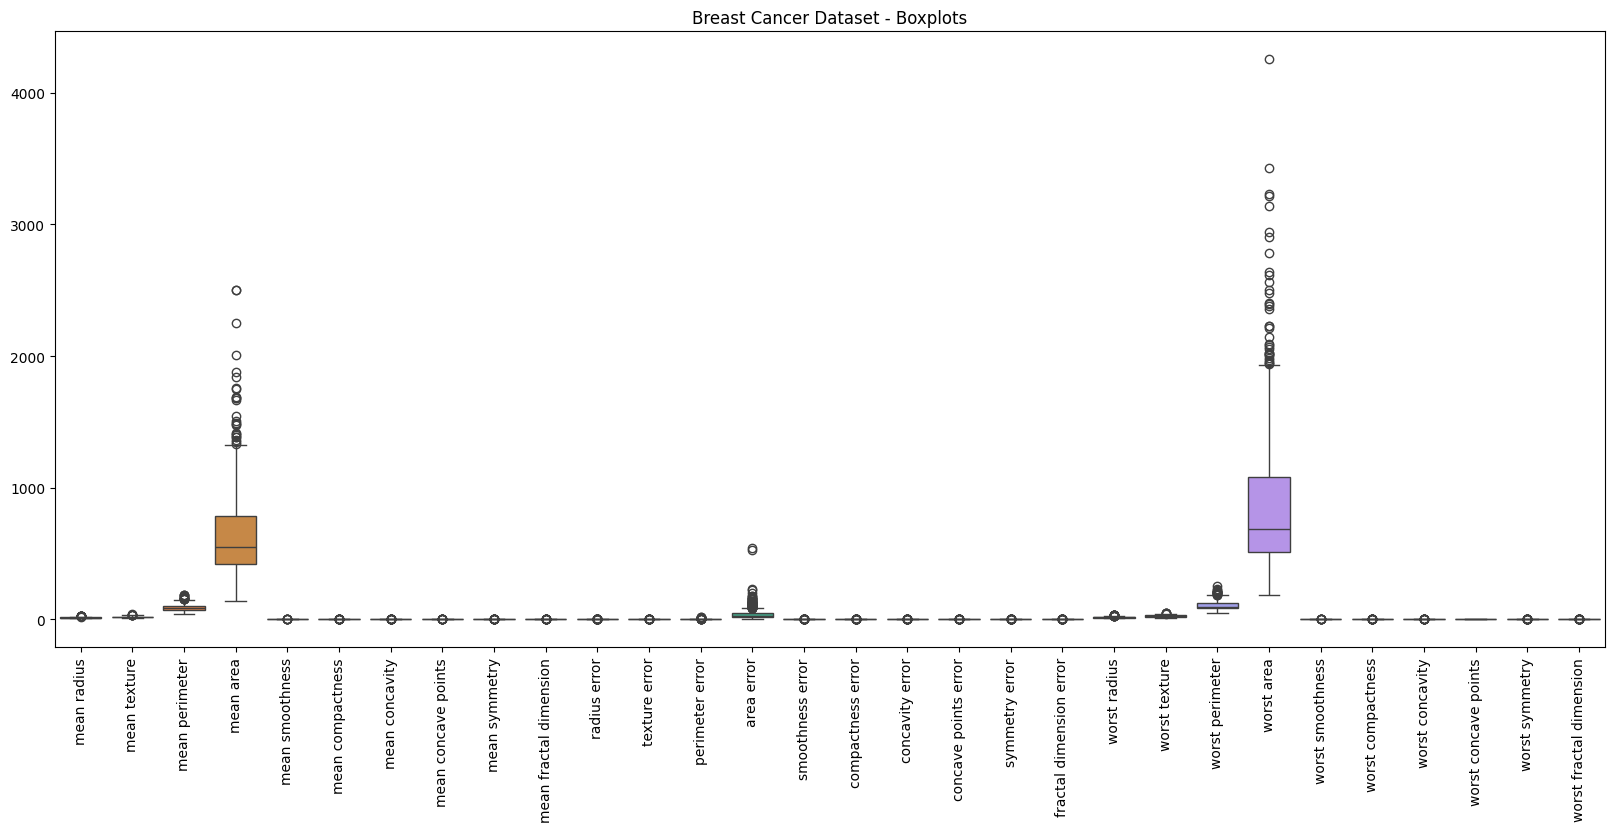

In [12]:
# STEP 7: Boxplots

# Iris Dataset
plt.figure(figsize=(10,6))
sns.boxplot(data=X_iris)
plt.title("Iris Dataset - Boxplots")
plt.xticks(rotation=45)
plt.show()

# Breast Cancer Dataset
plt.figure(figsize=(20,8))
sns.boxplot(data=X_cancer)
plt.title("Breast Cancer Dataset - Boxplots")
plt.xticks(rotation=90)
plt.show()

In [13]:
# STEP 8: Train-Test Split

# Iris Dataset
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris,
    y_iris,
    test_size=0.20,
    random_state=42,
    stratify=y_iris
)

# Breast Cancer Dataset
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=42,
    stratify=y_cancer
)

print("IRIS")
print("Training Shape:", X_train_iris.shape)
print("Testing Shape:", X_test_iris.shape)

print("\nBREAST CANCER")
print("Training Shape:", X_train_cancer.shape)
print("Testing Shape:", X_test_cancer.shape)

IRIS
Training Shape: (120, 4)
Testing Shape: (30, 4)

BREAST CANCER
Training Shape: (455, 30)
Testing Shape: (114, 30)


In [14]:
# STEP 9: Baseline Decision Tree

# Iris Dataset
dt_iris = DecisionTreeClassifier(random_state=42)
dt_iris.fit(X_train_iris, y_train_iris)

iris_train_pred = dt_iris.predict(X_train_iris)
iris_test_pred = dt_iris.predict(X_test_iris)

print("IRIS DATASET")
print("Training Accuracy:",
      accuracy_score(y_train_iris, iris_train_pred))
print("Testing Accuracy:",
      accuracy_score(y_test_iris, iris_test_pred))


# Breast Cancer Dataset
dt_cancer = DecisionTreeClassifier(random_state=42)
dt_cancer.fit(X_train_cancer, y_train_cancer)

cancer_train_pred = dt_cancer.predict(X_train_cancer)
cancer_test_pred = dt_cancer.predict(X_test_cancer)

print("\nBREAST CANCER DATASET")
print("Training Accuracy:",
      accuracy_score(y_train_cancer, cancer_train_pred))
print("Testing Accuracy:",
      accuracy_score(y_test_cancer, cancer_test_pred))

IRIS DATASET
Training Accuracy: 1.0
Testing Accuracy: 0.9333333333333333

BREAST CANCER DATASET
Training Accuracy: 1.0
Testing Accuracy: 0.9122807017543859


In [15]:
# STEP 10: Hyperparameter Tuning - IRIS

best_score_iris = 0
best_params_iris = None

for depth in [3, 5, 7, 10, None]:
    for split in [2, 5, 10]:
        for criterion in ['gini', 'entropy']:

            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                criterion=criterion,
                random_state=42
            )

            model.fit(X_train_iris, y_train_iris)

            score = model.score(X_test_iris, y_test_iris)

            if score > best_score_iris:
                best_score_iris = score
                best_params_iris = (depth, split, criterion)

print("Best Iris Accuracy:", best_score_iris)
print("Best Iris Parameters:", best_params_iris)

Best Iris Accuracy: 0.9666666666666667
Best Iris Parameters: (3, 2, 'gini')


In [16]:
# STEP 11: Hyperparameter Tuning - Breast Cancer

best_score_cancer = 0
best_params_cancer = None

for depth in [3, 5, 7, 10, None]:
    for split in [2, 5, 10]:
        for criterion in ['gini', 'entropy']:

            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                criterion=criterion,
                random_state=42
            )

            model.fit(X_train_cancer, y_train_cancer)

            score = model.score(X_test_cancer, y_test_cancer)

            if score > best_score_cancer:
                best_score_cancer = score
                best_params_cancer = (depth, split, criterion)

print("Best Cancer Accuracy:", best_score_cancer)
print("Best Cancer Parameters:", best_params_cancer)

Best Cancer Accuracy: 0.9473684210526315
Best Cancer Parameters: (3, 2, 'entropy')


In [17]:
# STEP 12: Final Tuned Decision Trees

# Iris Final Model
final_iris = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2,
    criterion='gini',
    random_state=42
)

final_iris.fit(X_train_iris, y_train_iris)

iris_train_acc = final_iris.score(X_train_iris, y_train_iris)
iris_test_acc = final_iris.score(X_test_iris, y_test_iris)

print("IRIS FINAL MODEL")
print("Training Accuracy:", iris_train_acc)
print("Testing Accuracy:", iris_test_acc)


# Breast Cancer Final Model
final_cancer = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2,
    criterion='entropy',
    random_state=42
)

final_cancer.fit(X_train_cancer, y_train_cancer)

cancer_train_acc = final_cancer.score(X_train_cancer, y_train_cancer)
cancer_test_acc = final_cancer.score(X_test_cancer, y_test_cancer)

print("\nBREAST CANCER FINAL MODEL")
print("Training Accuracy:", cancer_train_acc)
print("Testing Accuracy:", cancer_test_acc)

IRIS FINAL MODEL
Training Accuracy: 0.9833333333333333
Testing Accuracy: 0.9666666666666667

BREAST CANCER FINAL MODEL
Training Accuracy: 0.967032967032967
Testing Accuracy: 0.9473684210526315


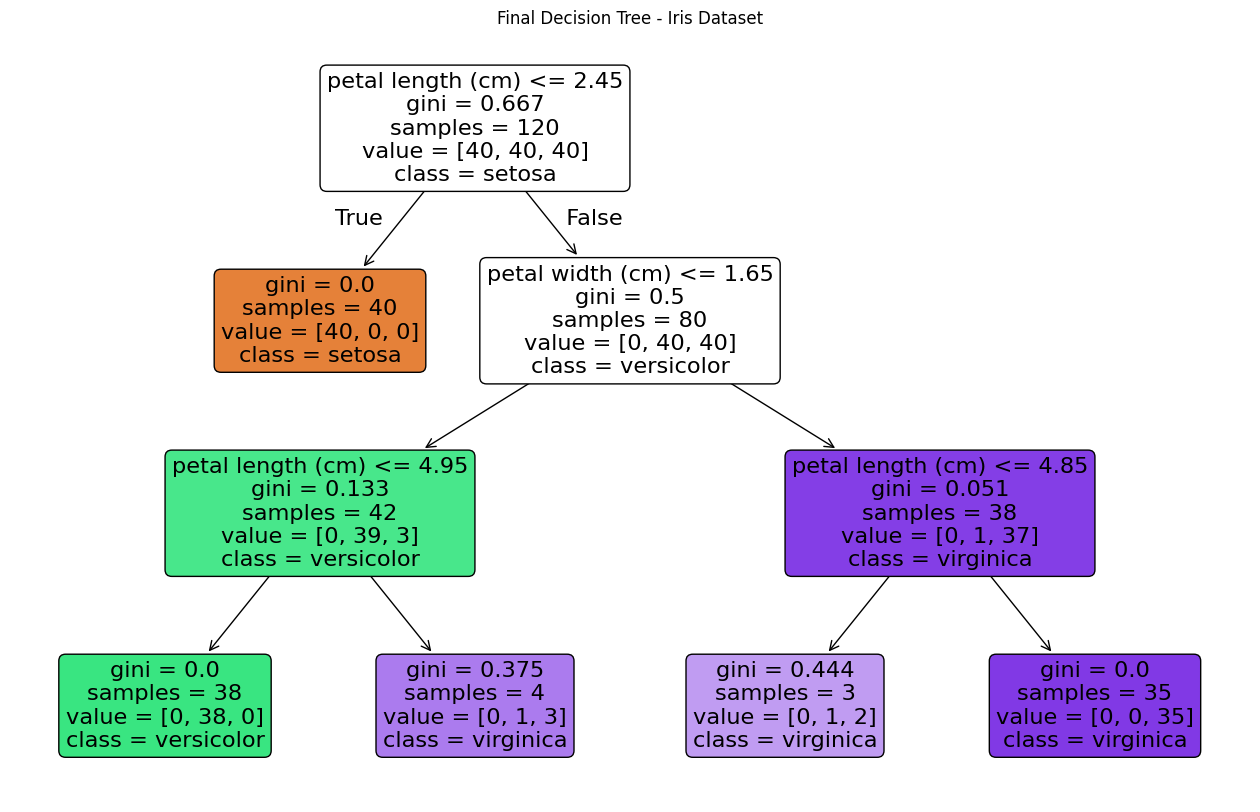

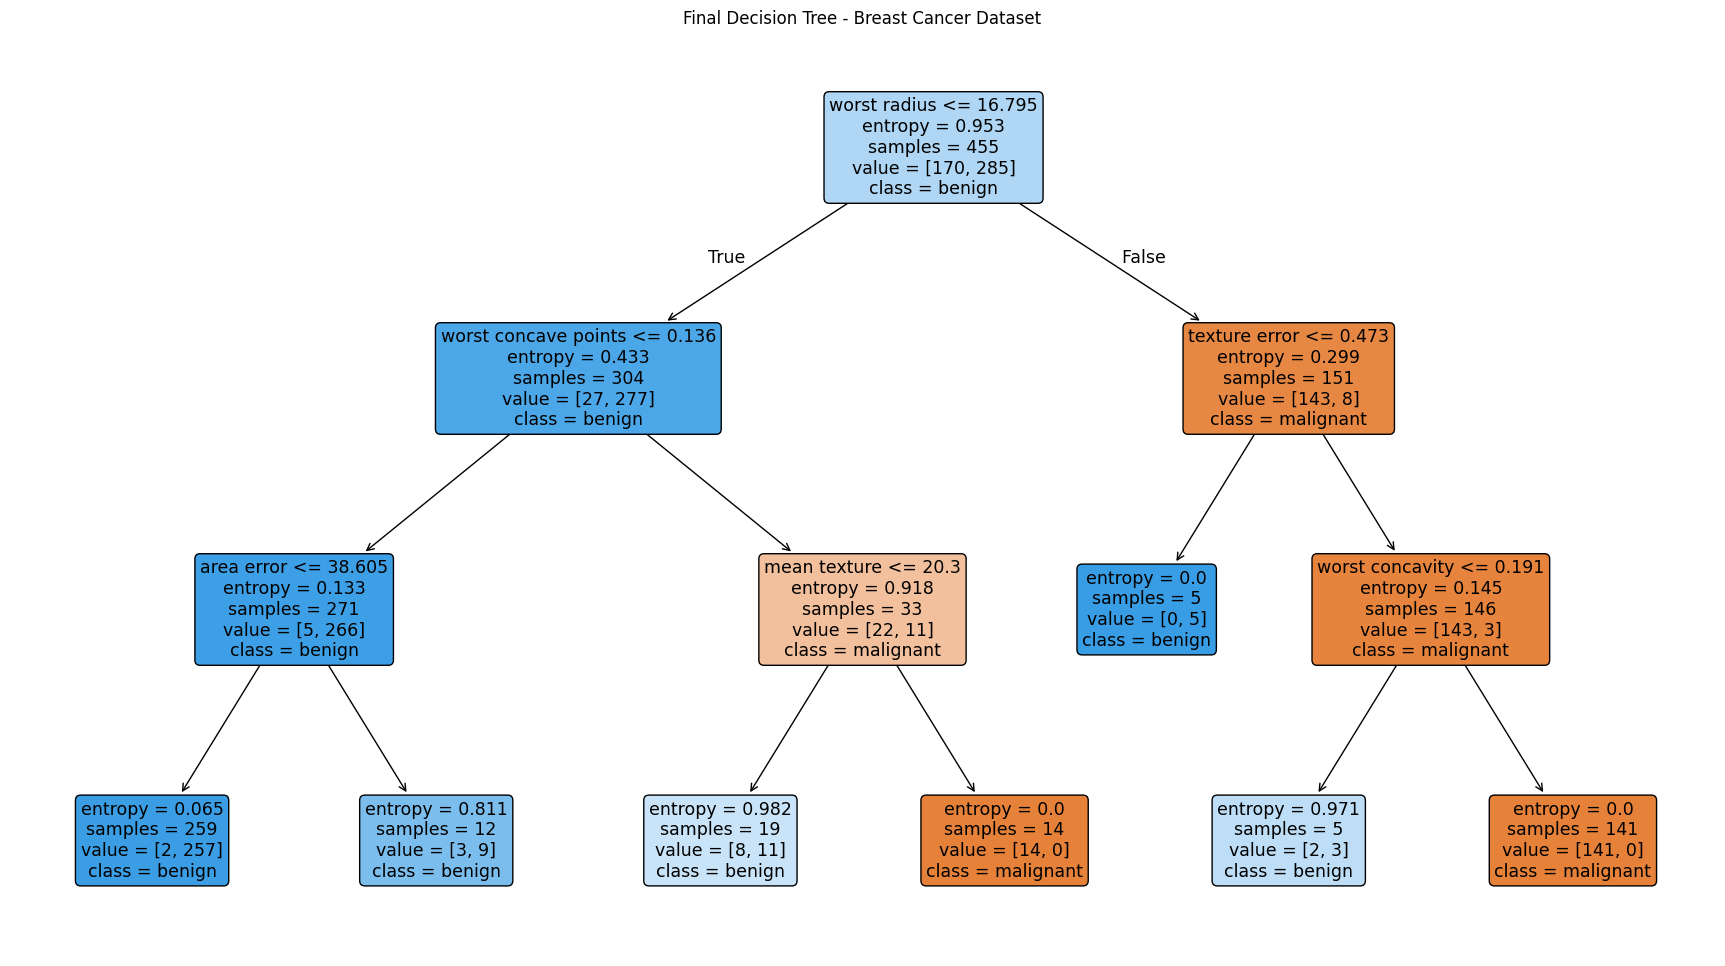

In [18]:
# STEP 13: Visualize Final Decision Trees

# Iris Tree
plt.figure(figsize=(16, 10))
plot_tree(
    final_iris,
    feature_names=X_iris.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Final Decision Tree - Iris Dataset")
plt.show()

# Breast Cancer Tree
plt.figure(figsize=(22, 12))
plot_tree(
    final_cancer,
    feature_names=X_cancer.columns,
    class_names=cancer.target_names,
    filled=True,
    rounded=True
)
plt.title("Final Decision Tree - Breast Cancer Dataset")
plt.show()

IRIS FEATURE IMPORTANCE
             Feature  Importance
2  petal length (cm)    0.579077
3   petal width (cm)    0.420923
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


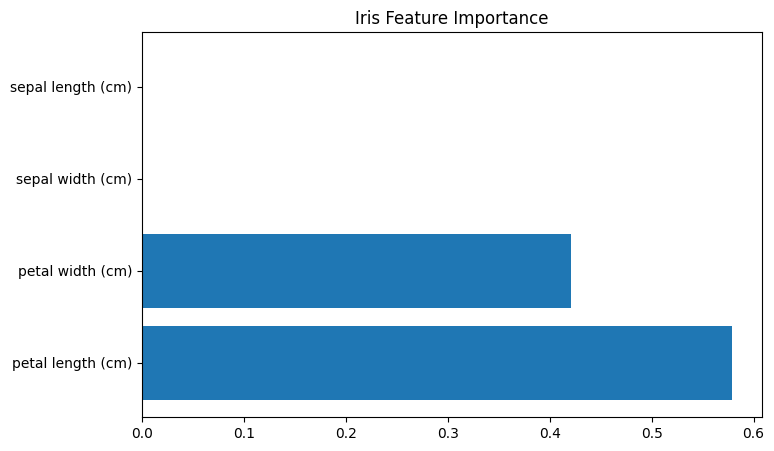


BREAST CANCER FEATURE IMPORTANCE
                 Feature  Importance
20          worst radius    0.670365
27  worst concave points    0.170025
11         texture error    0.062660
26       worst concavity    0.042339
1           mean texture    0.030358
13            area error    0.024252
5       mean compactness    0.000000
4        mean smoothness    0.000000
6         mean concavity    0.000000
7    mean concave points    0.000000


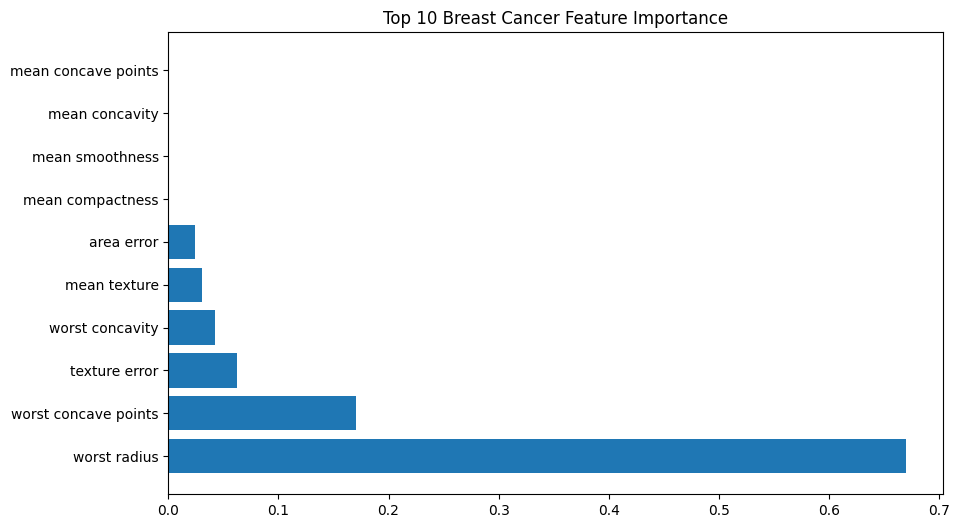

In [19]:
# STEP 14: Feature Importance Analysis

# Iris Feature Importance
iris_importance = pd.DataFrame({
    'Feature': X_iris.columns,
    'Importance': final_iris.feature_importances_
})

iris_importance = iris_importance.sort_values(
    by='Importance',
    ascending=False
)

print("IRIS FEATURE IMPORTANCE")
print(iris_importance)

plt.figure(figsize=(8,5))
plt.barh(
    iris_importance['Feature'],
    iris_importance['Importance']
)
plt.title("Iris Feature Importance")
plt.show()


# Breast Cancer Feature Importance
cancer_importance = pd.DataFrame({
    'Feature': X_cancer.columns,
    'Importance': final_cancer.feature_importances_
})

cancer_importance = cancer_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nBREAST CANCER FEATURE IMPORTANCE")
print(cancer_importance.head(10))

plt.figure(figsize=(10,6))
plt.barh(
    cancer_importance.head(10)['Feature'],
    cancer_importance.head(10)['Importance']
)
plt.title("Top 10 Breast Cancer Feature Importance")
plt.show()

In [24]:
scaler_iris = StandardScaler()

X_train_iris_sc = scaler_iris.fit_transform(X_train_iris)

X_test_iris_sc = scaler_iris.transform(X_test_iris)

In [29]:
# PART 3 : NAIVE BAYES IMPLEMENTATION
# 3-1 : GaussianNB

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

gnb_iris = GaussianNB()

gnb_iris.fit(X_train_iris_sc, y_train_iris)

nb_pred_iris = gnb_iris.predict(X_test_iris_sc)
nb_proba_iris = gnb_iris.predict_proba(X_test_iris_sc)

nb_train_acc_iris = accuracy_score(
    y_train_iris,
    gnb_iris.predict(X_train_iris_sc)
)

nb_test_acc_iris = accuracy_score(
    y_test_iris,
    nb_pred_iris
)

print(f"Train Accuracy: {nb_train_acc_iris:.4f}")
print(f"Test Accuracy: {nb_test_acc_iris:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_iris,
        nb_pred_iris,
        target_names=iris.target_names
    )
)

Train Accuracy: 0.9583
Test Accuracy: 0.9667

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



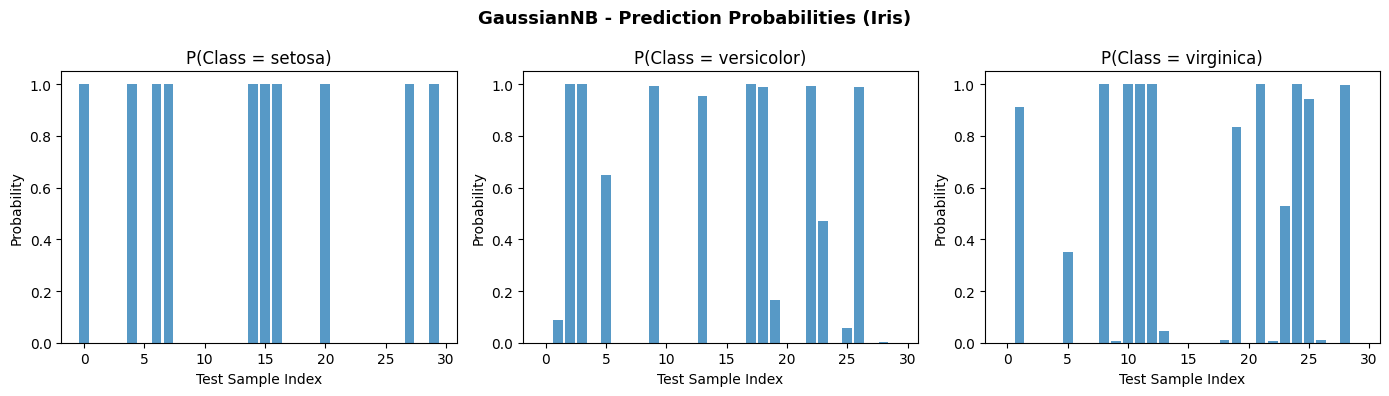

In [30]:
# 3-1.1 Prediction Probability Distributions – Iris
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14,4)
)

for cls_idx, cls_name in enumerate(
    iris.target_names
):

    axes[cls_idx].bar(
        range(len(nb_proba_iris)),
        nb_proba_iris[:, cls_idx],
        alpha=0.75
    )

    axes[cls_idx].set_title(
        f"P(Class = {cls_name})"
    )

    axes[cls_idx].set_xlabel(
        "Test Sample Index"
    )

    axes[cls_idx].set_ylabel(
        "Probability"
    )

plt.suptitle(
    "GaussianNB - Prediction Probabilities (Iris)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler

scaler_cancer = StandardScaler()

X_train_cancer_sc = scaler_cancer.fit_transform(
    X_train_cancer
)

X_test_cancer_sc = scaler_cancer.transform(
    X_test_cancer
)

In [34]:
# 3-2 GaussianNB – Breast Cancer
gnb_bc = GaussianNB()
gnb_bc.fit(
    X_train_cancer_sc,
    y_train_cancer
)

nb_pred_cancer = gnb_bc.predict(
    X_test_cancer_sc
)

nb_proba_cancer = gnb_bc.predict_proba(
    X_test_cancer_sc
)

nb_train_acc_cancer = accuracy_score(
    y_train_cancer,
    gnb_bc.predict(X_train_cancer_sc)
)

nb_test_acc_cancer = accuracy_score(
    y_test_cancer,
    nb_pred_cancer
)

print(f"Train Accuracy: {nb_train_acc_cancer:.4f}")
print(f"Test Accuracy: {nb_test_acc_cancer:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_cancer,
        nb_pred_cancer,
        target_names=cancer.target_names
    )
)

Train Accuracy: 0.9385
Test Accuracy: 0.9298

Classification Report

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [35]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='uniform'
)

X_iris_cat = kbd.fit_transform(X_iris)

In [36]:
X_train_icat, X_test_icat, y_train_icat, y_test_icat = train_test_split(
    X_iris_cat,
    y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

In [37]:
# 3-3 CategoricalNB – Iris Categorical
from sklearn.naive_bayes import CategoricalNB

cat_nb = CategoricalNB()

cat_nb.fit(
    X_train_icat,
    y_train_icat
)

nb_pred_icat = cat_nb.predict(
    X_test_icat
)

nb_proba_icat = cat_nb.predict_proba(
    X_test_icat
)

nb_train_acc_icat = accuracy_score(
    y_train_icat,
    cat_nb.predict(X_train_icat)
)

nb_test_acc_icat = accuracy_score(
    y_test_icat,
    nb_pred_icat
)

print(f"Train Accuracy: {nb_train_acc_icat:.4f}")
print(f"Test Accuracy: {nb_test_acc_icat:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        y_test_icat,
        nb_pred_icat,
        target_names=iris.target_names
    )
)

Train Accuracy: 0.9583
Test Accuracy: 0.9000

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [38]:
# 3-3.1 NB Variant Comparison
nb_comparison = pd.DataFrame({

    "Variant":[
        "GaussianNB (Iris)",
        "CategoricalNB (Iris-Categorical)"
    ],

    "Train Accuracy":[
        round(nb_train_acc_iris,4),
        round(nb_train_acc_icat,4)
    ],

    "Test Accuracy":[
        round(nb_test_acc_iris,4),
        round(nb_test_acc_icat,4)
    ]
})

nb_comparison

,Variant,Train Accuracy,Test Accuracy
0,GaussianNB (Iris),0.9583,0.9667
1,CategoricalNB (Iris-Categorical),0.9583,0.9000


In [50]:
# 4-1 Evaluation Function
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def full_metrics(
    y_true,
    y_pred,
    y_proba=None,
    average="weighted",
    binary=False
):

    metrics = {
           "Accuracy": accuracy_score(y_true, y_pred),
           "Precision": precision_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0
        )
    }

    if binary and y_proba is not None:

        metrics["ROC-AUC"] = roc_auc_score(
            y_true,
            y_proba[:,1]
        )

    return metrics

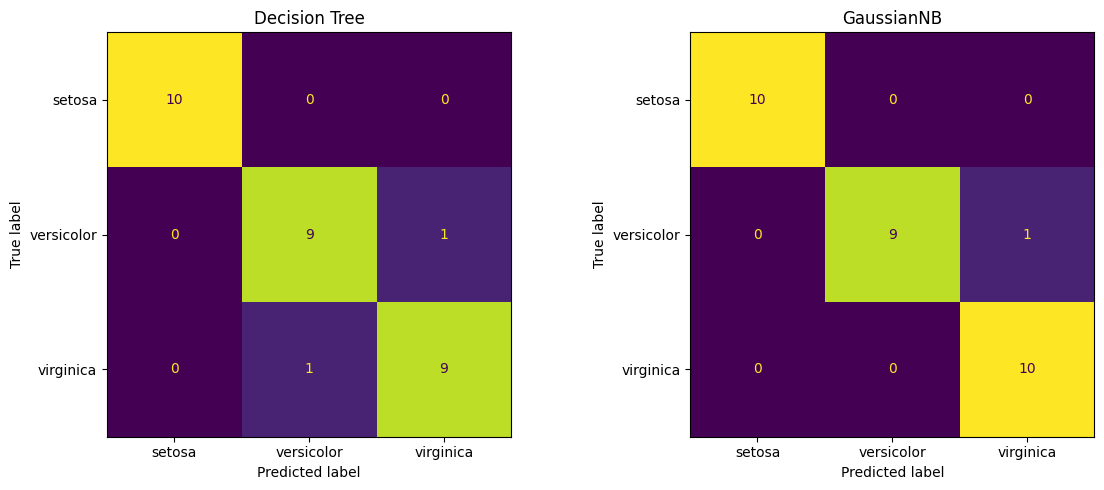

In [41]:
# 4-2 Confusion Matrix – Iris
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

for ax, preds, title in zip(

    axes,

    [iris_test_pred, nb_pred_iris],

    ["Decision Tree", "GaussianNB"]

):

    ConfusionMatrixDisplay(
        confusion_matrix(
            y_test_iris,
            preds
        ),
        display_labels=iris.target_names
    ).plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

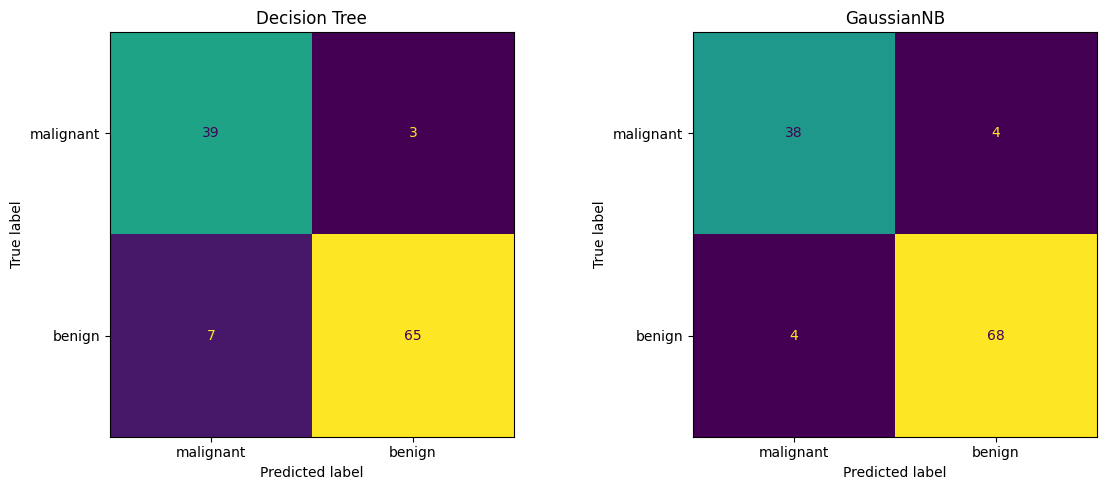

In [42]:
# 4-3 Confusion Matrix – Breast Cancer
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

for ax, preds, title in zip(

    axes,

    [cancer_test_pred, nb_pred_cancer],

    ["Decision Tree", "GaussianNB"]

):

    ConfusionMatrixDisplay(
        confusion_matrix(
            y_test_cancer,
            preds
        ),
        display_labels=cancer.target_names
    ).plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

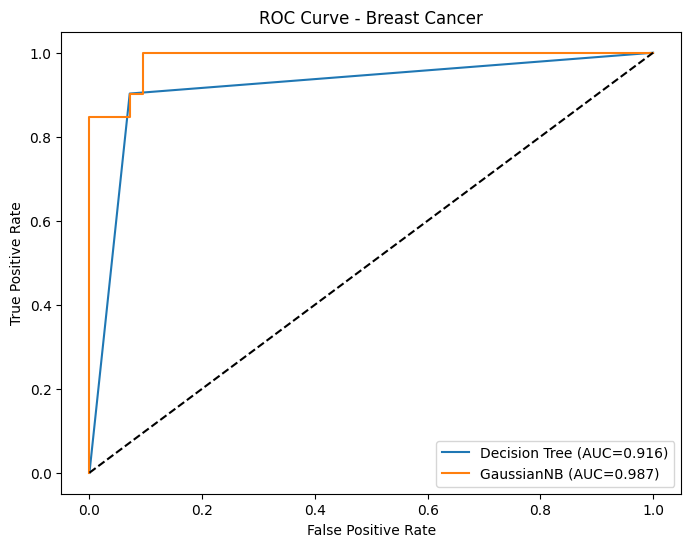

In [43]:
# 4-4 ROC Curve – Breast Cancer
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)
plt.figure(figsize=(8,6))
models = [
   (
        dt_cancer.predict_proba(
            X_test_cancer
        )[:,1],
        "Decision Tree"
    ),

    (
        gnb_bc.predict_proba(
            X_test_cancer_sc
        )[:,1],
        "GaussianNB"
    )
]

for probs, name in models:

    fpr, tpr, _ = roc_curve(
        y_test_cancer,
        probs
    )

    auc = roc_auc_score(
        y_test_cancer,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Breast Cancer"
)
plt.legend()
plt.show()

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_icat = DecisionTreeClassifier(
    random_state=42
)

dt_icat.fit(
    X_train_icat,
    y_train_icat
)

dt_pred_icat = dt_icat.predict(
    X_test_icat
)

dt_train_acc_icat = accuracy_score(
    y_train_icat,
    dt_icat.predict(X_train_icat)
)

dt_test_acc_icat = accuracy_score(
    y_test_icat,
    dt_pred_icat
)

print("Train Accuracy:", round(dt_train_acc_icat,4))
print("Test Accuracy:", round(dt_test_acc_icat,4))

Train Accuracy: 0.975
Test Accuracy: 0.9


In [46]:
# 4-5 Metrics Comparison Table
m_dt_iris = full_metrics(
    y_test_iris,
    iris_test_pred
)

m_nb_iris = full_metrics(
    y_test_iris,
    nb_pred_iris
)

m_dt_bc = full_metrics(
    y_test_cancer,
    cancer_test_pred,
    dt_cancer.predict_proba(X_test_cancer),
    average="binary",
    binary=True
)

m_nb_bc = full_metrics(
    y_test_cancer,
    nb_pred_cancer,
    gnb_bc.predict_proba(X_test_cancer_sc),
    average="binary",
    binary=True
)

m_dt_icat = full_metrics(
    y_test_icat,
    dt_pred_icat
)

m_nb_icat = full_metrics(
    y_test_icat,
    nb_pred_icat
)

comparison_table = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "DT Iris":[
        round(m_dt_iris["Accuracy"],4),
        round(m_dt_iris["Precision"],4),
        round(m_dt_iris["Recall"],4),
        round(m_dt_iris["F1-Score"],4)
    ],

    "NB Iris":[
        round(m_nb_iris["Accuracy"],4),
        round(m_nb_iris["Precision"],4),
        round(m_nb_iris["Recall"],4),
        round(m_nb_iris["F1-Score"],4)
    ],

    "DT Cancer":[
        round(m_dt_bc["Accuracy"],4),
        round(m_dt_bc["Precision"],4),
        round(m_dt_bc["Recall"],4),
        round(m_dt_bc["F1-Score"],4)
    ],

    "NB Cancer":[
        round(m_nb_bc["Accuracy"],4),
        round(m_nb_bc["Precision"],4),
        round(m_nb_bc["Recall"],4),
        round(m_nb_bc["F1-Score"],4)
    ],

    "DT Iris-Cat":[
        round(m_dt_icat["Accuracy"],4),
        round(m_dt_icat["Precision"],4),
        round(m_dt_icat["Recall"],4),
        round(m_dt_icat["F1-Score"],4)
    ],

    "CNB Iris-Cat":[
        round(m_nb_icat["Accuracy"],4),
        round(m_nb_icat["Precision"],4),
        round(m_nb_icat["Recall"],4),
        round(m_nb_icat["F1-Score"],4)
    ]
})

comparison_table

,Metric,DT Iris,NB Iris,DT Cancer,NB Cancer,DT Iris-Cat,CNB Iris-Cat
0,Accuracy,0.9333,0.9667,0.9123,0.9298,0.9000,0.9000
1,Precision,0.9333,0.9697,0.9559,0.9444,0.9024,0.9024
2,Recall,0.9333,0.9667,0.9028,0.9444,0.9000,0.9000
3,F1-Score,0.9333,0.9666,0.9286,0.9444,0.8997,0.8997


In [48]:
# 4-5.1 Add ROC-AUC Row
comparison_table.loc[len(comparison_table)] = [

    "ROC-AUC",

    "-",
    "-",

    round(m_dt_bc["ROC-AUC"],4),

    round(m_nb_bc["ROC-AUC"],4),

    "-",
    "-"
]

comparison_table

,Metric,DT Iris,NB Iris,DT Cancer,NB Cancer,DT Iris-Cat,CNB Iris-Cat
0,Accuracy,0.9333,0.9667,0.9123,0.9298,0.9,0.9
1,Precision,0.9333,0.9697,0.9559,0.9444,0.9024,0.9024
2,Recall,0.9333,0.9667,0.9028,0.9444,0.9,0.9
3,F1-Score,0.9333,0.9666,0.9286,0.9444,0.8997,0.8997
4,ROC-AUC,-,-,0.9157,0.9868,-,-


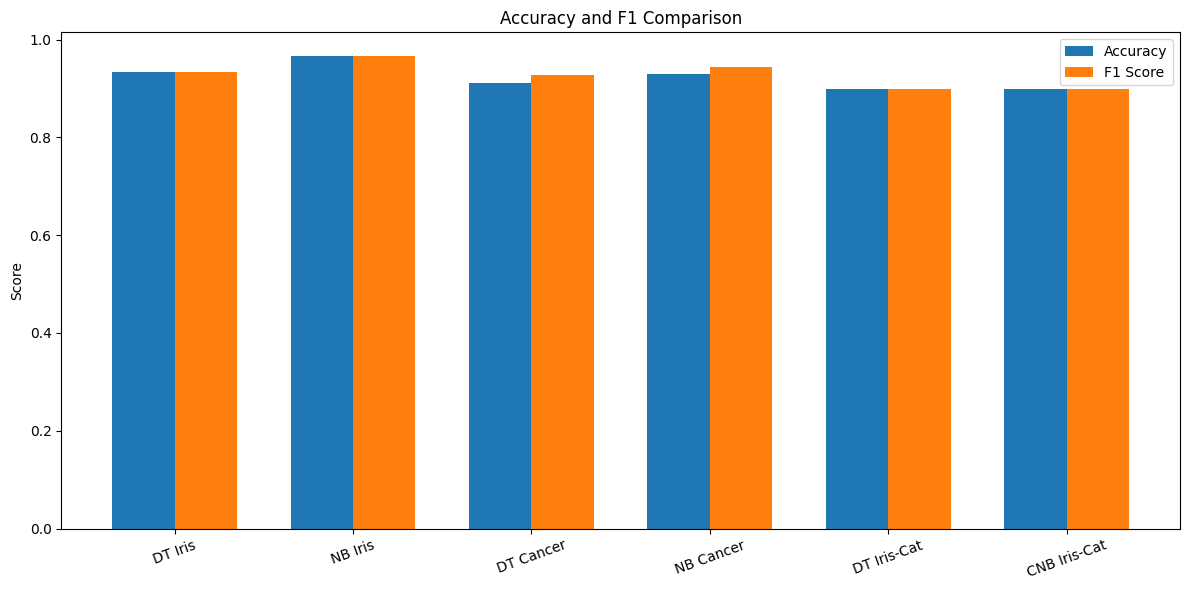

In [49]:
# 4-6 Accuracy & F1 Comparison Bar Chart
models = [

    "DT Iris",
    "NB Iris",

    "DT Cancer",
    "NB Cancer",

    "DT Iris-Cat",
    "CNB Iris-Cat"
]

accuracies = [

    m_dt_iris["Accuracy"],
    m_nb_iris["Accuracy"],

    m_dt_bc["Accuracy"],
    m_nb_bc["Accuracy"],

    m_dt_icat["Accuracy"],
    m_nb_icat["Accuracy"]
]

f1_scores = [

    m_dt_iris["F1-Score"],
    m_nb_iris["F1-Score"],

    m_dt_bc["F1-Score"],
    m_nb_bc["F1-Score"],

    m_dt_icat["F1-Score"],
    m_nb_icat["F1-Score"]
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x-width/2,
    accuracies,
    width,
    label="Accuracy"
)

plt.bar(
    x+width/2,
    f1_scores,
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    models,
    rotation=20
)

plt.ylabel("Score")
plt.title(
    "Accuracy and F1 Comparison"
)

plt.legend()

plt.tight_layout()
plt.show()